In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
!pip install -q torch torchvision Pillow numpy matplotlib
print("✅ Done")

✅ Done


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
import warnings
warnings.filterwarnings("ignore")

class AdaptiveToneMapping:
    @staticmethod
    def get_luminance(image):
        weights = torch.tensor([0.2126, 0.7152, 0.0722],
                               device=image.device).view(1, 3, 1, 1)
        return (image * weights).sum(dim=1, keepdim=True).clamp(min=1e-6)

    @staticmethod
    def adaptive_tone_map(image, sigma=1e-6):
        lw     = AdaptiveToneMapping.get_luminance(image)
        lw_bar = torch.exp(torch.mean(torch.log(sigma + lw), dim=[2,3], keepdim=True))
        lw_max = torch.amax(lw, dim=(2,3), keepdim=True)
        lg     = torch.log(lw / lw_bar + 1) / (torch.log(lw_max / lw_bar + 1) + 1e-6)
        scale  = lg / (lw + 1e-6)
        return (image * scale).clamp(0, 1)

    @staticmethod
    def pre_enhance(image):
        return AdaptiveToneMapping.adaptive_tone_map(image)


class DownBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch,  out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.LeakyReLU(0.2, inplace=True),
        )
        self.pool = nn.MaxPool2d(2, 2)

    def forward(self, x):
        feat = self.block(x)
        return self.pool(feat), feat


class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch,  out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.LeakyReLU(0.2, inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class RefinementNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1   = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2   = ConvBlock(32,  32)
        self.down1   = DownBlock(32,  32)
        self.down2   = DownBlock(32,  64)
        self.down3   = DownBlock(64,  128)
        self.down4   = DownBlock(128, 256)
        self.conv3   = ConvBlock(256, 512)
        self.conv4   = ConvBlock(512, 512)
        self.up1     = nn.Sequential(
                           nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True),
                           nn.Conv2d(512, 256, 1))
        self.fusion1 = ConvBlock(256+128, 256)
        self.up2     = nn.Sequential(
                           nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True),
                           nn.Conv2d(256, 128, 1))
        self.fusion2 = ConvBlock(128+64, 128)
        self.up3     = nn.Sequential(
                           nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True),
                           nn.Conv2d(128, 64, 1))
        self.fusion3 = ConvBlock(64+32, 64)
        self.up4     = nn.Sequential(
                           nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True),
                           nn.Conv2d(64, 32, 1))
        self.fusion4 = ConvBlock(32+32, 32)
        self.conv5   = nn.Conv2d(32, 3, 1)

    @staticmethod
    def _crop(skip, ref):
        return skip[:, :, :ref.shape[2], :ref.shape[3]]

    def forward(self, x):
        x1       = self.conv1(x)
        s2       = self.conv2(x1)
        x3, s3   = self.down1(s2)
        x4, s4   = self.down2(x3)
        x5, s5   = self.down3(x4)
        x6, _    = self.down4(x5)
        x7       = self.conv3(x6)
        x8       = self.conv4(x7)
        u1       = self.up1(x8)
        d        = self.fusion1(torch.cat([u1, self._crop(s5, u1)], dim=1))
        u2       = self.up2(d)
        d        = self.fusion2(torch.cat([u2, self._crop(s4, u2)], dim=1))
        u3       = self.up3(d)
        d        = self.fusion3(torch.cat([u3, self._crop(s3, u3)], dim=1))
        u4       = self.up4(d)
        d        = self.fusion4(torch.cat([u4, self._crop(s2, u4)], dim=1))
        return torch.sigmoid(self.conv5(d))

print("✅ Architecture defined")

✅ Architecture defined


In [7]:
import os
folder = "/kaggle/input/models/devdeepmukherjee/lol-enhancement/pytorch/default/1"
print(os.listdir(folder))

['ckpt_1000.pth']


In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ⬇️ Change this path to wherever your .pth is in /kaggle/input/
CKPT_PATH = "/kaggle/input/models/devdeepmukherjee/lol-enhancement/pytorch/default/1/ckpt_1000.pth"

G = RefinementNet().to(device)
ckpt = torch.load(CKPT_PATH, map_location=device)
G.load_state_dict(ckpt["G"])
G.eval()
print(f"✅ Model loaded! Trained for {ckpt['epoch']} epochs")

Using device: cpu
✅ Model loaded! Trained for 1000 epochs


In [12]:
import numpy as np
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt
from pathlib import Path
import torch

def compute_psnr(img1, img2):
    """Compute PSNR between two numpy images in [0,1]."""
    # Resize img2 to match img1 if needed
    if img1.shape != img2.shape:
        h, w = img1.shape[:2]
        img2 = np.array(
            Image.fromarray((img2 * 255).astype(np.uint8)).resize((w, h), Image.BILINEAR)
        ).astype(np.float32) / 255.0
    mse = np.mean((img1 - img2) ** 2)
    return 10 * np.log10(1.0 / mse) if mse > 0 else 100.0


def enhance(image_path, save_path=None, gt_path=None):
    """
    Enhance any dark image using the trained model.
    image_path : path to input image (jpg/png)
    save_path  : optional path to save the enhanced output
    gt_path    : optional path to ground truth image for PSNR
    """
    # ── Load ──────────────────────────────────────────────────────────
    img = Image.open(image_path).convert("RGB")
    print(f"Input size: {img.size}")

    low = transforms.ToTensor()(img).unsqueeze(0).to(device)   # [1,3,H,W]

    # ── Inference ─────────────────────────────────────────────────────
    with torch.no_grad():
        pre     = AdaptiveToneMapping.pre_enhance(low)
        refined = G(pre)

    # ── To numpy ──────────────────────────────────────────────────────
    to_np = lambda t: t.squeeze().permute(1, 2, 0).cpu().numpy().clip(0, 1)
    inp  = to_np(low)
    pre_ = to_np(pre)
    out  = to_np(refined)

    # ── PSNR ──────────────────────────────────────────────────────────
    psnr_val = None
    if gt_path:
        gt       = np.array(Image.open(gt_path).convert("RGB")).astype(np.float32) / 255.0
        psnr_val = compute_psnr(out, gt)
        print(f"PSNR: {psnr_val:.2f} dB")

    # ── Plot ──────────────────────────────────────────────────────────
    n_cols = 4 if gt_path else 3
    fig, axes = plt.subplots(1, n_cols, figsize=(6 * n_cols, 6))

    images = [inp, pre_, out]
    titles = ["🌑 Input (dark)", "🌤 Stage 1 (tone mapped)", "☀️ Stage 2 (final output)"]

    if gt_path:
        gt_np  = np.array(Image.open(gt_path).convert("RGB")).astype(np.float32) / 255.0
        images.append(gt_np)
        titles.append("🎯 Ground Truth")

    for ax, arr, title in zip(axes, images, titles):
        ax.imshow(arr)
        ax.set_title(title, fontsize=13)
        ax.axis("off")

    psnr_str = f"   |   PSNR: {psnr_val:.2f} dB" if psnr_val else ""
    plt.suptitle(f"Low-Light Enhancement  |  {Path(image_path).name}{psnr_str}", fontsize=14)
    plt.tight_layout()
    plt.show()

    # ── Save ──────────────────────────────────────────────────────────
    if save_path:
        result = (out * 255).astype(np.uint8)
        Image.fromarray(result).save(save_path)
        print(f"✅ Saved to: {save_path}")

    return out, psnr_val


# ── Bulk evaluation with mean PSNR ────────────────────────────────────────────
def evaluate_folder(low_folder, gt_folder=None, save_folder=None):
    """
    Run enhance() on all images in a folder.
    Prints per-image and mean PSNR if gt_folder is provided.
    """
    low_folder  = Path(low_folder)
    save_folder = Path(save_folder) if save_folder else None
    if save_folder:
        save_folder.mkdir(parents=True, exist_ok=True)

    psnr_scores = []

    for img_path in sorted(low_folder.glob("*")):
        if img_path.suffix.lower() not in {".jpg", ".jpeg", ".png", ".bmp"}:
            continue

        gt_path   = Path(gt_folder) / img_path.name if gt_folder else None
        save_path = str(save_folder / f"{img_path.stem}_enhanced.jpg") if save_folder else None

        print(f"\n── {img_path.name} ──")
        _, psnr = enhance(str(img_path), save_path=save_path,
                          gt_path=str(gt_path) if gt_path and gt_path.exists() else None)
        if psnr:
            psnr_scores.append(psnr)

    if psnr_scores:
        print(f"\n{'='*40}")
        print(f"Mean PSNR over {len(psnr_scores)} images: {np.mean(psnr_scores):.3f} dB")
        print(f"Min : {np.min(psnr_scores):.2f} dB")
        print(f"Max : {np.max(psnr_scores):.2f} dB")
        print(f"{'='*40}")

    return psnr_scores


print("✅ enhance() and evaluate_folder() ready")

✅ enhance() and evaluate_folder() ready


Input size: (600, 400)


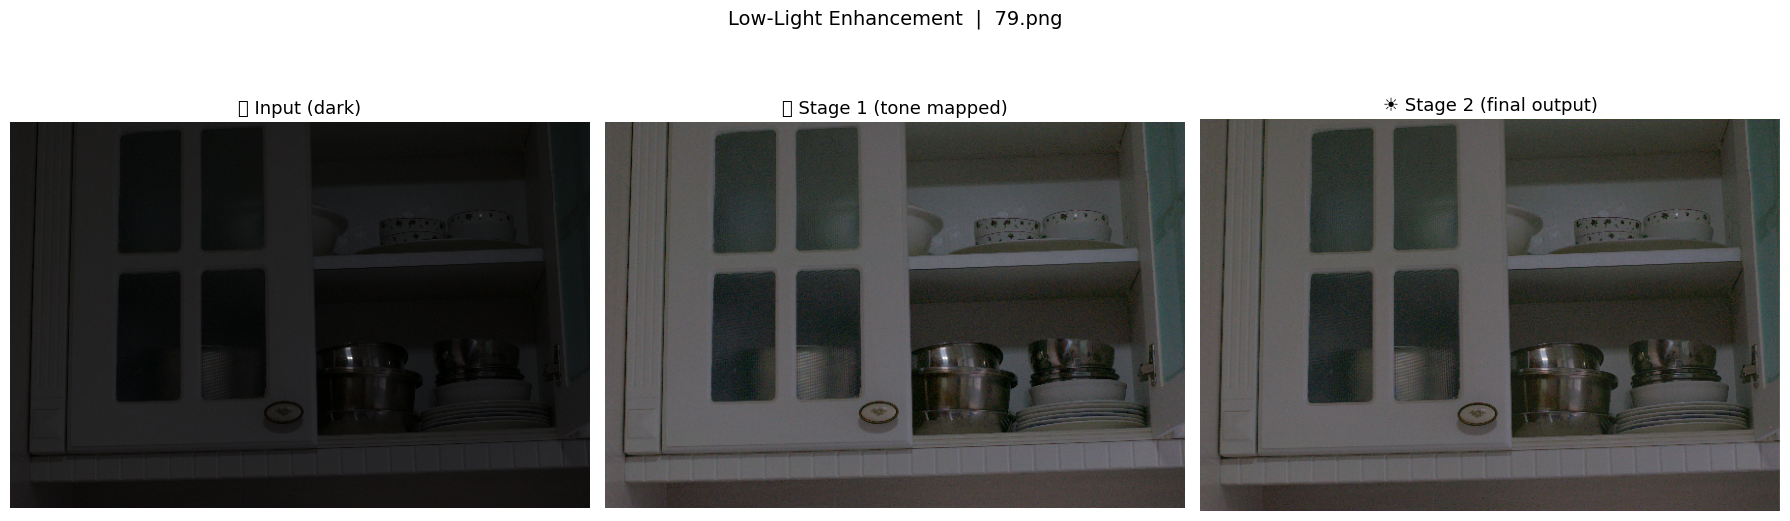

✅ Saved to: /kaggle/working/enhanced_1.jpg

✅ All done! Check /kaggle/working/ for saved results


In [13]:
from pathlib import Path

# ── Option A: single image you uploaded ──────────────────────────────
enhance(
    image_path = "/kaggle/input/datasets/devdeepmukherjee/image1/79.png",
    save_path  = "/kaggle/working/enhanced_1.jpg"
)

# ── Option B: run on ALL images in a folder ───────────────────────────
test_folder = Path("/kaggle/input/your-test-images/")

for img_path in sorted(test_folder.glob("*.jpg")):
    print(f"\nProcessing: {img_path.name}")
    enhance(
        image_path = str(img_path),
        save_path  = f"/kaggle/working/{img_path.stem}_enhanced.jpg"
    )

print("\n✅ All done! Check /kaggle/working/ for saved results")

Input size: (600, 400)


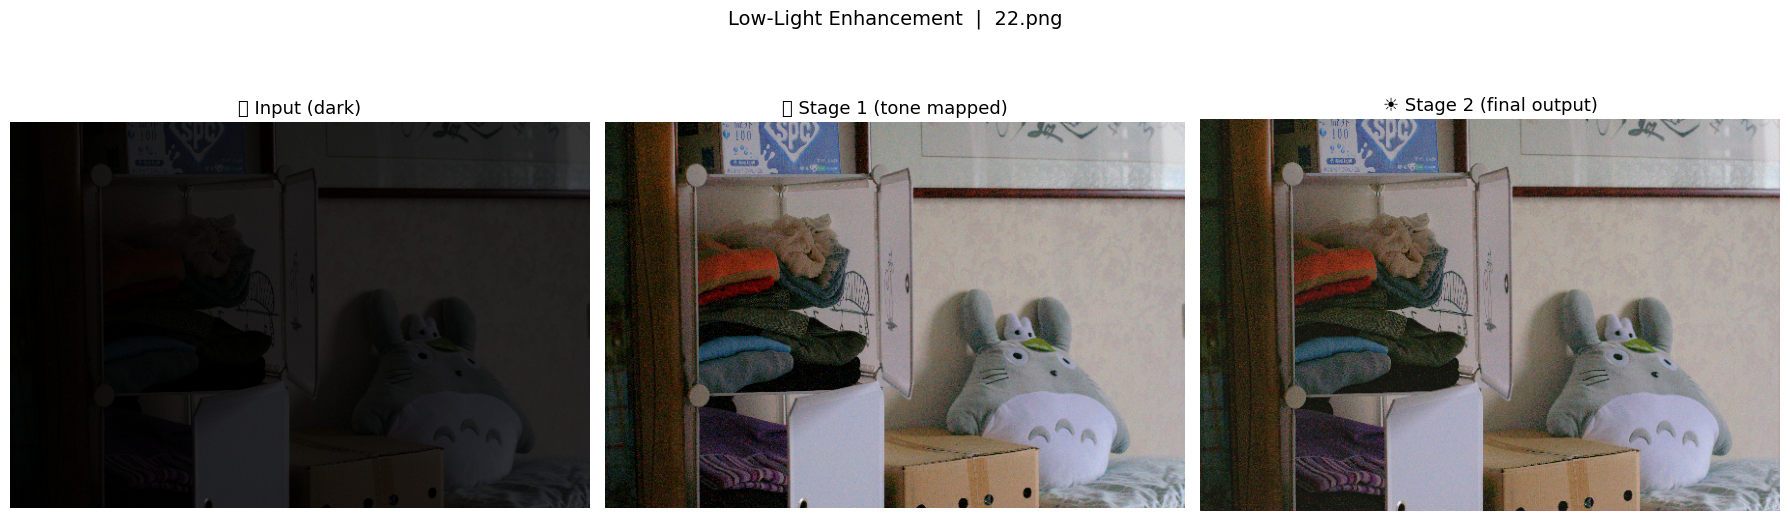

PSNR: 18.35 dB


In [23]:
def compute_psnr(img1_np, gt_path):
    """Compute PSNR between enhanced numpy array and ground truth image path."""
    gt = np.array(Image.open(gt_path).convert("RGB")).astype(np.float32) / 255.0

    # Resize gt to match if needed
    if img1_np.shape != gt.shape:
        h, w = img1_np.shape[:2]
        gt = np.array(
            Image.fromarray((gt * 255).astype(np.uint8)).resize((w, h), Image.BILINEAR)
        ).astype(np.float32) / 255.0

    mse = np.mean((img1_np - gt) ** 2)
    return 10 * np.log10(1.0 / mse) if mse > 0 else 100.0


# Unpack the tuple properly
out, _ = enhance("/kaggle/input/datasets/devdeepmukherjee/image5/22.png")
psnr = compute_psnr(out, "/kaggle/input/datasets/devdeepmukherjee/image6/22.png")
print(f"PSNR: {psnr:.2f} dB")